In [25]:
import os
import numpy as np
import pandas as pd

# List to store the NumPy arrays (equivalent to std::vector<ArrayXXi> in C++)
age_matrix_vec_2050 = []

# Directory containing the binary files
data_dir = "../../output/20250620_101235_2940/population"

# Read each binary file
for i in range(8):
    filename = os.path.join(data_dir, f"forecast_matrix_{i}.bin")
    
    # Get file size to determine number of rows
    file_size = os.path.getsize(filename)
    num_rows = file_size // (27 * 4)  # 27 columns, 4 bytes per int32
    
    # Create numpy matrix of appropriate size
    matrix = np.zeros((num_rows, 27), dtype=np.int32)
    
    # Read binary data into matrix
    with open(filename, 'rb') as f:
        # Read all values at once into flattened array
        data = np.fromfile(f, dtype=np.int32)
        # Reshape into matrix
        matrix = data.reshape((num_rows, 27))
    
    age_matrix_vec_2050.append(matrix)

# remove death people from the matrices
for idx in range(8):
    matrix = age_matrix_vec_2050[idx]  # Extract the matrix
    # Check each row, and keep it if not all values are negative
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec_2050[idx] = filtered_matrix

In [8]:
# Load pre 1990 population 
N = 8 

age_dict = [{} for _ in range(N)]
for i in range(N):
    ages = age_matrix_vec_2050[i][:,0]
    # convert ages of 18 - 85 
    for age in ages:
        if age >= 18 and age <= 85:
            if age not in age_dict[i]:
                age_dict[i][age] = 1
            else:
                age_dict[i][age] += 1

In [ ]:
# Save all matrices to future_data/age_matrix directory
# save_dir = "future_data/age_matrix"
# os.makedirs(save_dir, exist_ok=True)

# for i, matrix in enumerate(age_matrix_vec_2050):
#     filename = os.path.join(save_dir, f"age_matrix_{i}.npy")
#     np.save(filename, matrix)

# Load matrices and print their shape
age_matrix_vec_2050 = []
for i in range(8):
    filename = os.path.join(save_dir, f"age_matrix_{i}.npy")
    matrix = np.load(filename)
    age_matrix_vec_2050.append(matrix)
    print(f"Matrix {i} shape: {matrix.shape}")

Matrix 0 shape: (92749, 27)
Matrix 1 shape: (98107, 27)
Matrix 2 shape: (20330, 27)
Matrix 3 shape: (20266, 27)
Matrix 4 shape: (16226, 27)
Matrix 5 shape: (14384, 27)
Matrix 6 shape: (13465, 27)
Matrix 7 shape: (14927, 27)


In [3]:
age_matrix_vec = age_matrix_vec_2050

# Convert all age matrices to integer type to fix IndexError
for i in range(len(age_matrix_vec)):
    age_matrix_vec[i] = age_matrix_vec[i].astype(int)
    print(f"age_matrix_vec[{i}] data type after conversion: {age_matrix_vec[i].dtype}")

age_matrix_vec[0] data type after conversion: int64
age_matrix_vec[1] data type after conversion: int64
age_matrix_vec[2] data type after conversion: int64
age_matrix_vec[3] data type after conversion: int64
age_matrix_vec[4] data type after conversion: int64
age_matrix_vec[5] data type after conversion: int64
age_matrix_vec[6] data type after conversion: int64
age_matrix_vec[7] data type after conversion: int64


In [ ]:
from impute_albu import schedule_pre_albuminuria_probability,schedule_albuminuria_probability

from prevalence import get_prevalence,get_pre_prevalence,get_overall_prevalence,get_overall_pre_prevalence


In [6]:
N = 8

In [9]:
# get 1990 
albu_status_dict = {}
albu_mat_list_overall = []
A_range = [0.001, 0.005]

for A in A_range:
    albu_status_dict = {}
    for group in range(N):
        i = group
        albu_status_dict[group] = {}
        albu_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1]))  
        for age in age_dict[group]:
            # bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
            #n_samples, n_ages = bmi_samples.shape
            # Create an age matrix with shape (n_samples, n_ages)
            n_samples = age_dict[group][age]
            age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))
            # idx = group

            # Compute prediabetes probability matrix
            prediabetes_prob_matrix = schedule_pre_albuminuria_probability(age_mat,i,A)
            rand_matrix = np.random.rand(*age_mat.shape)
            prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
            prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

            # Compute albu probability matrix
            albu_prob_matrix = schedule_albuminuria_probability(age_mat,i)
            rand_matrix = np.random.rand(*age_mat.shape)
            albu_matrix = np.where(rand_matrix < albu_prob_matrix, 1, 0.5)

            # Combine: take max along each row (for each sample)
            combined_matrix = np.where(prediabetes_matrix == 0.5, albu_matrix, prediabetes_matrix)
            combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

            albu_status_dict[group][age] = np.max(combined_matrix, axis=1)

    
    albu_mat_list = []
    pre_albu_mat_list = []
    for i in range(8):
        albu_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1] ))  
        for age, status_vec in albu_status_dict[i].items():
            # Find positions where the first column of age_matrix_vec[i] equals 'age'
            positions = np.where(age_matrix_vec[i][:, 0] == age)[0]
            # Assign the albu status vector for this age group
            albu_status[positions, 0] = status_vec

        n_cols = age_matrix_vec[i].shape[1]
        albu_status_before = np.repeat(albu_status[:, 0][:, np.newaxis], n_cols, axis=1)
        # Process albu status
        # bmi_mat = bmi_matrix_ls[i]
        age_mat = age_matrix_vec[i]

        pre_albu_prob_matrix = schedule_pre_albuminuria_probability(age_mat, i, A)
        rand_matrix = np.random.rand(*age_mat.shape)
        pre_albu_matrix = (rand_matrix < pre_albu_prob_matrix) * 0.5
        
        pre_albu_matrix = np.where(albu_status_before == 0, pre_albu_matrix, albu_status_before)
        pre_albu_matrix = np.maximum.accumulate(pre_albu_matrix, axis=1)
        pre_albu_mat_list.append(pre_albu_matrix)
        
        albu_prob_matrix = schedule_albuminuria_probability(age_mat, i)
        rand_matrix = np.random.rand(*age_mat.shape)
        albu_matrix = np.where(rand_matrix < albu_prob_matrix, 1, 0.5)
        
        combined_matrix = np.where(pre_albu_matrix == 0.5, albu_matrix, pre_albu_matrix)

        albu_status[:, 1:] = combined_matrix[:, 1:]
        albu_status = np.maximum.accumulate(albu_status, axis=1)
        albu_mat_list.append(albu_status)

    overall_prevalence = get_overall_prevalence(age_matrix_vec,albu_mat_list,-2)
    overall_pre_prevalence = get_overall_pre_prevalence(age_matrix_vec,albu_mat_list,-2)

    print(f"A = {A}: Overall prevalence = {overall_prevalence:.4f}, Overall pre-prevalence = {overall_pre_prevalence:.4f}")
    
    # Store the albu_mat_list for this A value
    albu_mat_list_overall.append(albu_mat_list)






A = 0.001: Overall prevalence = 0.0090, Overall pre-prevalence = 0.0606
A = 0.005: Overall prevalence = 0.0310, Overall pre-prevalence = 0.1660


In [14]:
# Load albuminuria matrices for different A values
import os

# Load albu_mat_list_overall for different A values
albu_dir = '../future_data/albu_matrix/'

A_range = [0.002, 0.005]
N = 8

# Create albu_1_mat_storage: list of arrays where each array has shape (len(A_range), albu_matrix.shape[0], albu_matrix.shape[1])
albu_mat_storage = []

# For each group i, create an array that stacks matrices from all A values
for i in range(N):
    # Get the shape from the first A value's matrix for group i
    first_matrix = albu_mat_list_overall[0][i]  # A_range[0], group i
    matrix_shape = first_matrix.shape
    
    # Initialize array to hold matrices for all A values for this group
    group_array = np.zeros((len(A_range), matrix_shape[0], matrix_shape[1]))
    
    # Fill the array with matrices from each A value
    for A_idx in range(len(A_range)):
        group_array[A_idx] = albu_mat_list_overall[A_idx][i]
    
    albu_mat_storage.append(group_array)


In [16]:
# check the prevalence of albu
albu_mat_list = []
pre_albu_mat_list = []
for matrix in albu_mat_storage:
        # Extract the first 2D slice (mat[0,:,:]) and append to list
        matrix_2d = matrix[0, :, :]
        albu_mat_list.append(matrix_2d)
        
for k in range(-27, 0):    
    overall_prevalence = get_overall_prevalence(age_matrix_vec, albu_mat_list, k)   
    pre_albu_mat_list.append(overall_prevalence)

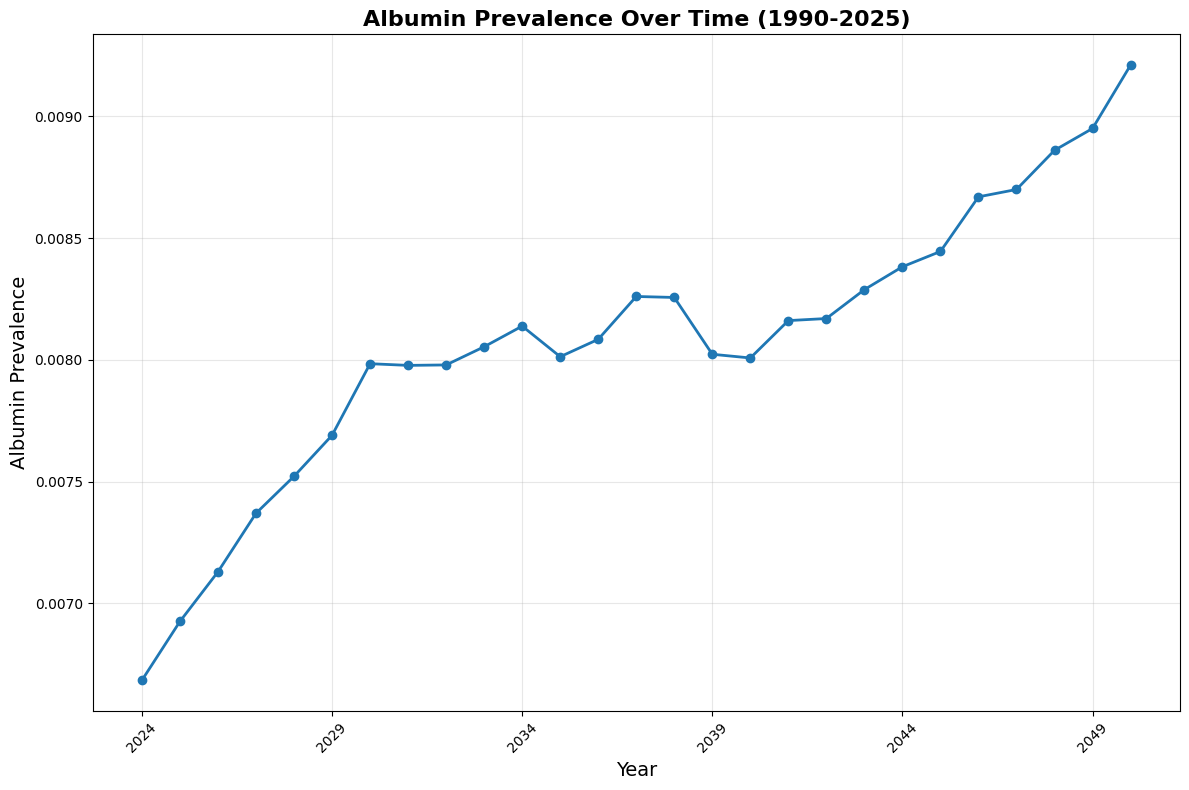

Number of data points: 27
Starting prevalence (1964): 0.006684
Ending prevalence (2024): 0.009211
Change over time: 0.002527


In [18]:
import matplotlib.pyplot as plt

# Create years array from 1990 to 2025 (36 years)
years = list(range(2024, 2051))

# Plot the prevalence data
plt.figure(figsize=(12, 8))
plt.plot(years[:len(pre_albu_mat_list)], pre_albu_mat_list, marker='o', linewidth=2, markersize=6)
plt.title('Albumin Prevalence Over Time (1990-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Albumin Prevalence', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(2024, 2051, 5), rotation=45)
plt.tight_layout()
plt.show()

# Print some summary statistics
print(f"Number of data points: {len(pre_albu_mat_list)}")
print(f"Starting prevalence (1964): {pre_albu_mat_list[0]:.6f}")
print(f"Ending prevalence (2024): {pre_albu_mat_list[-1]:.6f}")
print(f"Change over time: {pre_albu_mat_list[-1] - pre_albu_mat_list[0]:.6f}")

In [23]:
# Load the saved albumin prevalence data
try:
    loaded_albu_data = np.load('../future_data_1990_2050/albumin_prevalence_1990_2025.npy')
    print(f"Successfully loaded albumin prevalence data from ../future_data_1990_2050/albumin_prevalence_1990_2025.npy")
   
except FileNotFoundError:
    print("Error: Could not find the albumin prevalence data file")
    print("Please make sure the file exists at ../future_data_1990_2050/albumin_prevalence_1990_2025.npy")
except Exception as e:
    print(f"Error loading data: {e}")


Successfully loaded albumin prevalence data from ../future_data_1990_2050/albumin_prevalence_1990_2025.npy


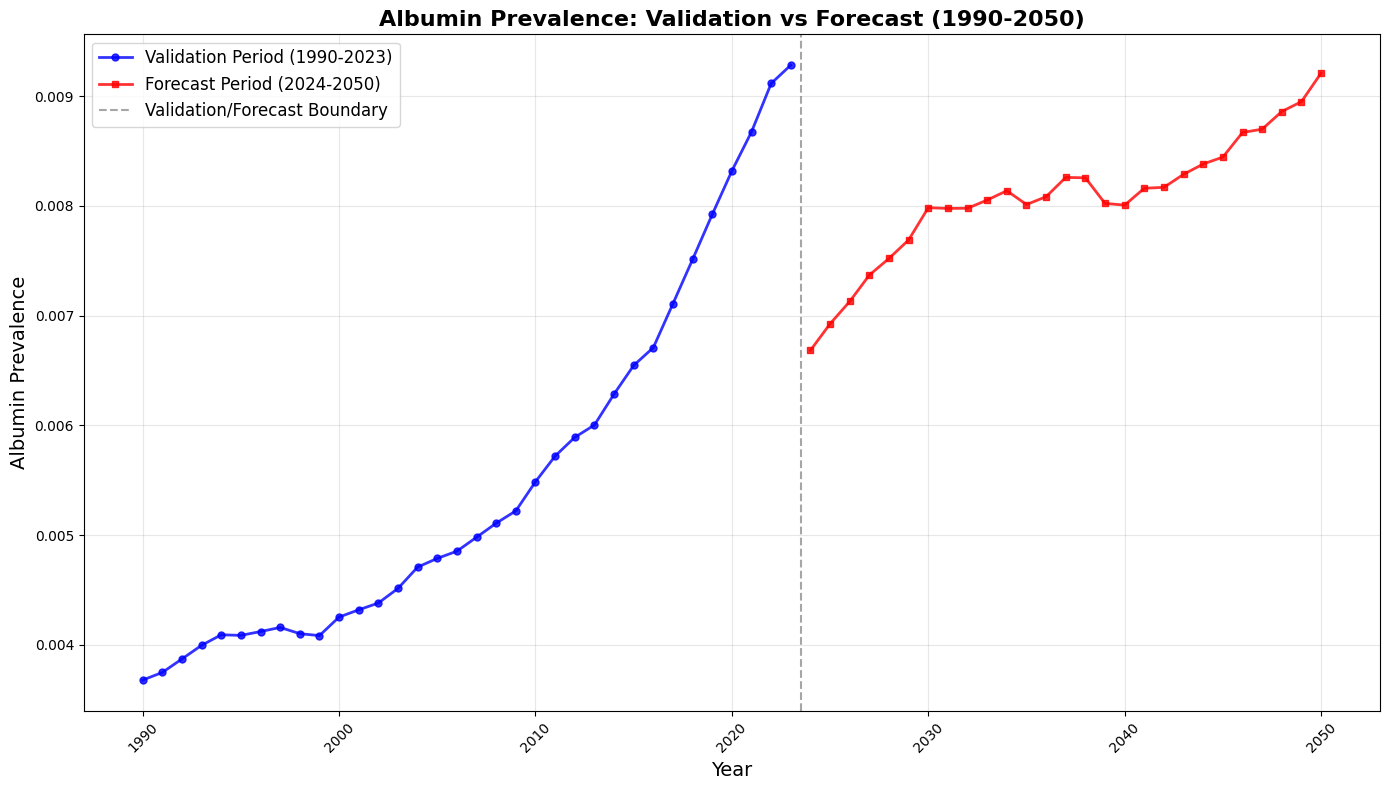


=== Data Summary ===
Validation period (1990-2023):
  Number of points: 34
  Starting prevalence (1990): 0.003679
  Ending prevalence (2023): 0.009284
  Change during validation: 0.005606

Forecast period (2024-2050):
  Number of points: 27
  Starting prevalence (2024): 0.006684
  Ending prevalence (2050): 0.009211
  Change during forecast: 0.002527

Overall period (1990-2050):
  Total number of points: 61
  Overall change: 0.005532


In [24]:
# Combine the loaded albumin data (1990-2025) and predicted data (2024-2050)
# Note: There might be overlap at 2024-2025, so we'll handle that

import matplotlib.pyplot as plt
import numpy as np

# Create year arrays
validation_years = list(range(1990, 2024))  # 1990-2023 (34 years)
forecast_years = list(range(2024, 2051))    # 2024-2050 (27 years)

# Handle the data combination
if len(loaded_albu_data) >= 34:
    # Use first 34 points for validation period (1990-2023)
    validation_data = loaded_albu_data[:34]
else:
    print(f"Warning: loaded_albu_data has only {len(loaded_albu_data)} points, expected at least 34")
    validation_data = loaded_albu_data

# Use pre_albu_mat_list for forecast period (2024-2050)
forecast_data = pre_albu_mat_list

# Combine all years and data
all_years = validation_years + forecast_years
all_data = list(validation_data) + forecast_data

# Create the plot
plt.figure(figsize=(14, 8))

# Plot validation period (1990-2023)
plt.plot(validation_years, validation_data, marker='o', linewidth=2, markersize=5, 
         color='blue', label='Validation Period (1990-2023)', alpha=0.8)

# Plot forecast period (2024-2050)
plt.plot(forecast_years, forecast_data, marker='s', linewidth=2, markersize=5, 
         color='red', label='Forecast Period (2024-2050)', alpha=0.8)

# Add vertical line to separate validation and forecast periods
plt.axvline(x=2023.5, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, 
            label='Validation/Forecast Boundary')

# Customize the plot
plt.title('Albumin Prevalence: Validation vs Forecast (1990-2050)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Albumin Prevalence', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(range(1990, 2051, 10), rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== Data Summary ===")
print(f"Validation period (1990-2023):")
print(f"  Number of points: {len(validation_data)}")
print(f"  Starting prevalence (1990): {validation_data[0]:.6f}")
print(f"  Ending prevalence (2023): {validation_data[-1]:.6f}")
print(f"  Change during validation: {validation_data[-1] - validation_data[0]:.6f}")

print(f"\nForecast period (2024-2050):")
print(f"  Number of points: {len(forecast_data)}")
print(f"  Starting prevalence (2024): {forecast_data[0]:.6f}")
print(f"  Ending prevalence (2050): {forecast_data[-1]:.6f}")
print(f"  Change during forecast: {forecast_data[-1] - forecast_data[0]:.6f}")

print(f"\nOverall period (1990-2050):")
print(f"  Total number of points: {len(all_data)}")
print(f"  Overall change: {all_data[-1] - all_data[0]:.6f}")
